# Safety Filtering
```Author: Kensuke Nakamura```

```Acknowledgements: MPPI planner and Intent Lab floorplans from Leonardo Santos```



In this, we will computationally synthesize and deploy a *safety filter*. We will use Hamilton-Jacobi (HJ) reachability as our safety filter synthesis tool. This will involve computing a backward reachable tube (BRT) for our dynamical system of choice.


In [30]:
# # @title Install and import dependencies
# !gdown 1UATUlH4Xer6qq5XN4UoFoVZT0OSLSkeR
# !pip install --upgrade pip
# !pip install "flax>=0.6.6"
# !pip install -U "jax[cuda12]"
# !pip install "numpy>=1.22"
# !pip install --upgrade hj-reachability

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Select GPU 1
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [32]:
# for directories and paths
import os

# for math operations
import numpy as np
import scipy

# for plotting
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as anim
import matplotlib.pyplot as plt

# for accelerated computing
import jax
import jax.numpy as jnp

# Python reachability toolbox
import hj_reachability as hj

In [33]:
# @title 3D Dubins Car Dynamics
import jax.numpy as jnp

from hj_reachability import dynamics
from hj_reachability import sets
import torch

speed = 1.
class Dubins3D(dynamics.ControlAndDisturbanceAffineDynamics):
    def __init__(self,
                 max_turn_rate=1.25,
                 control_mode="max",
                 disturbance_mode="min",
                 control_space=None,
                 disturbance_space=None):
        self.speed = speed
        if control_space is None:
            control_space = sets.Box(jnp.array([-max_turn_rate]), jnp.array([max_turn_rate]))
        if disturbance_space is None:
            disturbance_space = sets.Box(jnp.array([0, 0]), jnp.array([0, 0]))
        super().__init__(control_mode, disturbance_mode, control_space, disturbance_space)

    def open_loop_dynamics(self, state, time):
        _, _, psi = state
        v = self.speed
        return jnp.array([v * jnp.cos(psi), v * jnp.sin(psi), 0.])

    def control_jacobian(self, state, time):
        x, y, _ = state
        return jnp.array([
            [0],
            [0],
            [1],
        ])

    def disturbance_jacobian(self, state, time):
        return jnp.array([
            [1., 0.],
            [0., 1.],
            [0., 0.],
        ])


def dubins_dynamics_tensor(current_state: torch.Tensor, action: torch.Tensor, dt: float) \
        -> torch.Tensor:
    """
    current_state: shape(num_samples, dim_x)
    action: shape(num_samples, dim_u)

    Implemented discrete time dynamics with RK-4.

    return:
    next_state: shape(num_samples, dim_x)
    """

    def one_step_dynamics(state, action):
        """Compute the derivatives [dx/dt, dy/dt, dtheta/dt]."""
        x_dot = speed*torch.cos(state[:, 2])
        y_dot = speed*torch.sin(state[:, 2])
        theta_dot = action[:, 0]
        return torch.stack([y_dot, x_dot, theta_dot], dim=1)

    # k1
    k1 = one_step_dynamics(current_state, action)
    # k2
    mid_state_k2 = current_state + 0.5 * dt * k1
    k2 = one_step_dynamics(mid_state_k2, action)
    # k3
    mid_state_k3 = current_state + 0.5 * dt * k2
    k3 = one_step_dynamics(mid_state_k3, action)
    # k4
    end_state_k4 = current_state + dt * k3
    k4 = one_step_dynamics(end_state_k4, action)
    # Combine k1, k2, k3, k4 to compute the next state
    next_state = current_state + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    next_state[..., -1] = next_state[..., -1] % (2 * np.pi)
    return next_state


In [34]:
import jax.numpy as jnp
from hj_reachability import dynamics, sets  # adjust these imports to your project layout

def is_inside_failure_set(state_xy, center, radius):
    return jnp.linalg.norm(state_xy - jnp.array(center)) < radius

def heat_dynamics(
    state_xy,
    center,
    radius=0.5,
    r_hot=12/(255/1.1)/0.05,   # interpreted as a rate (per second)
    r_cool=20/(255/1.1)/0.05,  # interpreted as a rate (per second)
):
    """
    Returns dh/dt based on whether (x, y) is inside the failure (hot) region.
    """
    distance = jnp.linalg.norm(state_xy - jnp.array(center))
    return jnp.where(distance < radius, r_hot, -r_cool)

class Dubins3DWithHeat(dynamics.ControlAndDisturbanceAffineDynamics):
    """
    Dubins car with heat and longitudinal acceleration.

    State:      x, y, psi, v, h
    Control u:  [omega, a]        -> omega = yaw rate, a = longitudinal acceleration
    Disturb d:  [wx, wy]          -> additive to xdot, ydot (e.g., wind bias)

    Dynamics (control-affine):
      xdot = v * cos(psi) + wx
      ydot = v * sin(psi) + wy
      psidot = omega
      vdot = a
      hdot = heat_dynamics(x, y)

    So:
      f(x) = [v cos psi, v sin psi, 0, 0, dh]^T
      G(x) = [[0, 0],
              [0, 0],
              [1, 0],
              [0, 1],
              [0, 0]]
      D(x) = [[1, 0],
              [0, 1],
              [0, 0],
              [0, 0],
              [0, 0]]
    """
    def __init__(self,
                 max_turn_rate=1.25,
                 max_accel=1.0,
                 control_mode="max",
                 disturbance_mode="min",
                 control_space=None,
                 disturbance_space=None,
                 failure_center=(0.0, 0.0),
                 failure_radius=0.5):
        self.failure_center = jnp.array(failure_center, dtype=jnp.float32)
        self.failure_radius = float(failure_radius)

        # Controls: [omega, a]
        if control_space is None:
            control_space = sets.Box(
                jnp.array([-max_turn_rate, -max_accel], dtype=jnp.float32),
                jnp.array([+max_turn_rate, +max_accel], dtype=jnp.float32),
            )

        # Disturbances: [wx, wy] (set to 0..0 if you don't want disturbances)
        if disturbance_space is None:
            disturbance_space = sets.Box(
                jnp.array([0.0, 0.0], dtype=jnp.float32),
                jnp.array([0.0, 0.0], dtype=jnp.float32),
            )

        super().__init__(control_mode, disturbance_mode, control_space, disturbance_space)

    def open_loop_dynamics(self, state, time):
        """
        Drift term f(x, t). No direct control here; controls come via control_jacobian.
        """
        x, y, psi, v, h = state
        dh = heat_dynamics(jnp.array([x, y]), center=self.failure_center, radius=self.failure_radius)
        return jnp.array([
            v * jnp.cos(psi),  # dx/dt (plus disturbance)
            v * jnp.sin(psi),  # dy/dt (plus disturbance)
            0.0,               # dpsi/dt from control omega
            0.0,               # dv/dt from control acceleration
            dh                 # dh/dt from heat model
        ])

    def control_jacobian(self, state, time):
        """
        G(x, t) mapping control u = [omega, a] to state derivatives.
        psidot = 1*omega, vdot = 1*a
        """
        return jnp.array([
            [0.0, 0.0],  # x
            [0.0, 0.0],  # y
            [1.0, 0.0],  # psi
            [0.0, 1.0],  # v
            [0.0, 0.0],  # h
        ])

    def disturbance_jacobian(self, state, time):
        """
        D(x, t) mapping disturbance d = [wx, wy] additively into xdot and ydot.
        """
        return jnp.array([
            [1.0, 0.0],  # x
            [0.0, 1.0],  # y
            [0.0, 0.0],  # psi
            [0.0, 0.0],  # v
            [0.0, 0.0],  # h
        ])


In [35]:
dim = 31

In [36]:
import jax.numpy as jnp
import numpy as np
import hj_reachability as hj

# Define the dynamical system (with 5D state)
dyn_sys = Dubins3DWithHeat()

# Grid bounds for: x, y, psi, v, h
grid_min = np.array([-1.5, -1.5, 0., 0., 0.])       # meters, radians, m/s, heat
grid_max = np.array([1.5,  1.5, 2 * np.pi, 1., 1.0]) # meters, radians, m/s, heat

num_cells = (dim, dim, dim, dim, dim)

# Define grid (with periodicity on heading dimension = index 2)
grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    hj.sets.Box(grid_min, grid_max),
    num_cells,
    periodic_dims=(2,)
)

# Define failure set
x_c, y_c, radius = -0.0, -0.0, 0.5
h_max = 0.8  # Unsafe if heat > 0.8

# Signed distance from unsafe heat threshold (lower => more unsafe)
# Heat is state dimension 4
heat_sd = h_max - grid.states[..., 4]  # V = 0 at h = h_max
failure_lx = heat_sd

# Solver setup
solver_settings = hj.SolverSettings.with_accuracy(
    "very_high",
    hamiltonian_postprocessor=hj.solver.backwards_reachable_tube,
)

# Time grid: simulate backward from t=0 to t=-2.8 with step dt
dt = 0.05
time_values = jnp.arange(0.0, -2.8 - dt, -dt)  # negative time = backward reachability

# Solve HJ PDE for backwards reachable tube
target_values = hj.solve(solver_settings, dyn_sys, grid, time_values, failure_lx)


2025-08-04 14:54:12.234048: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.08GiB (rounded to 6527446528)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-08-04 14:54:12.234119: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] **************________________________________________________*************************x___________*
E0804 14:54:12.234134  356350 pjrt_stream_executor_client.cc:2916] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 6527446428 bytes. [tf-allocator-allocation-error='']


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 6527446428 bytes.

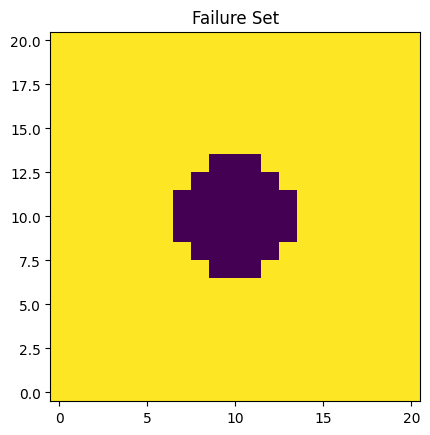

In [ ]:
obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - grid.states[..., :2], axis=-1) - radius

plt.title("Failure Set")
plt.imshow(obstacle1[:, :, 20, 20, 20].T > 0, origin='lower')
plt.show()

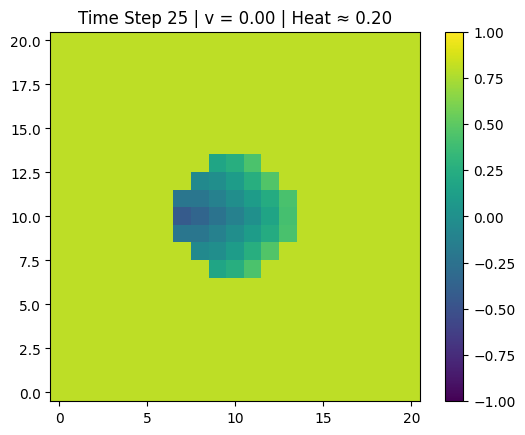

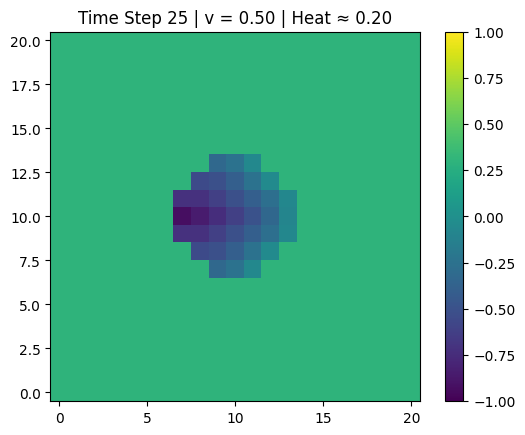

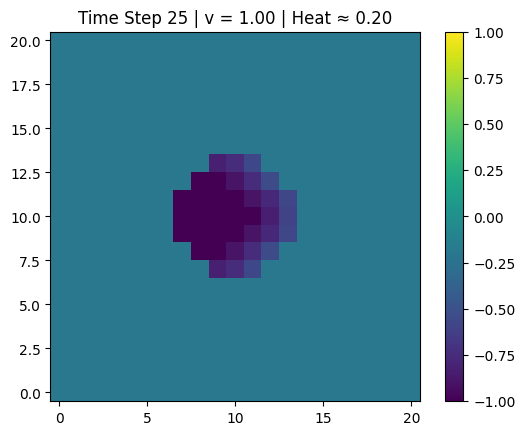

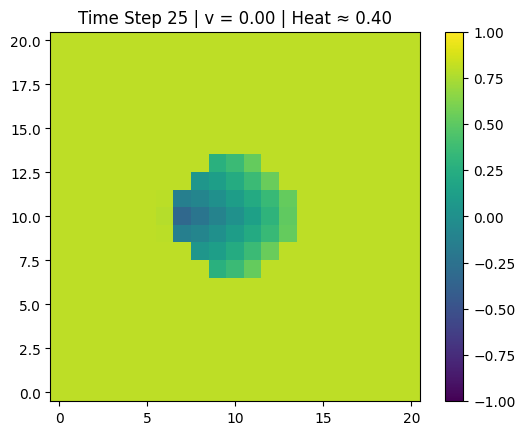

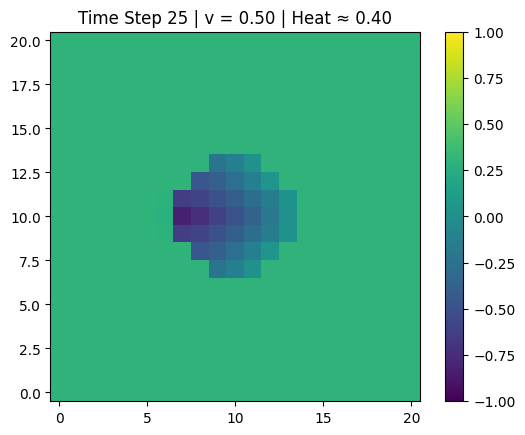

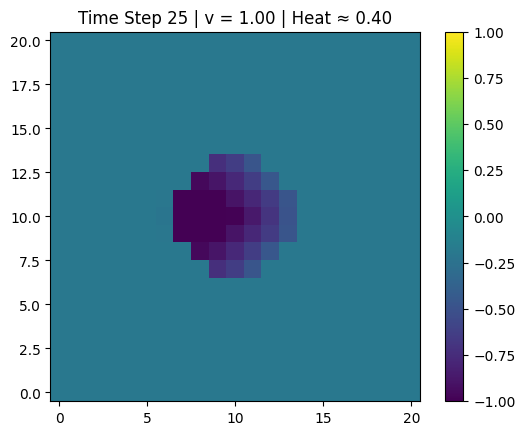

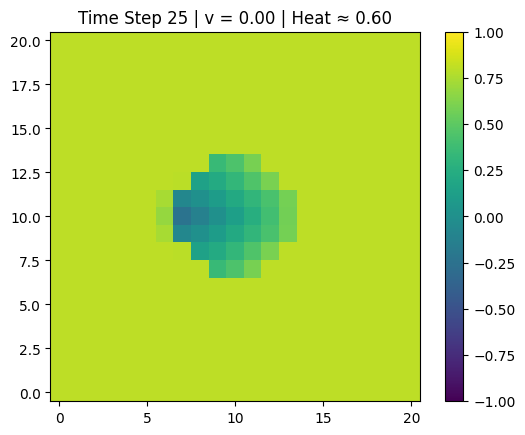

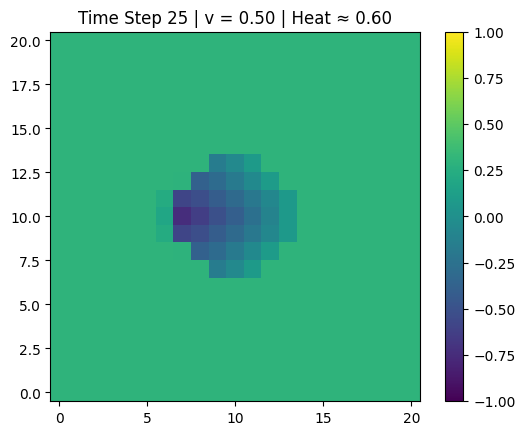

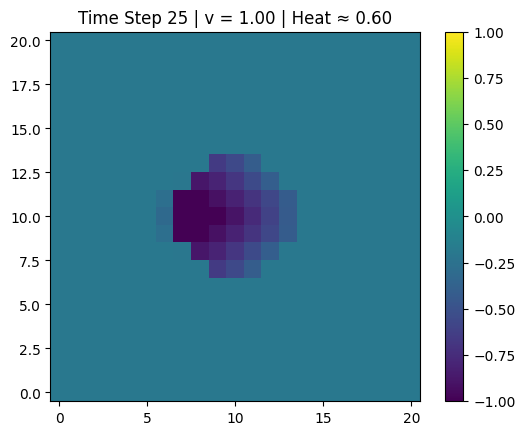

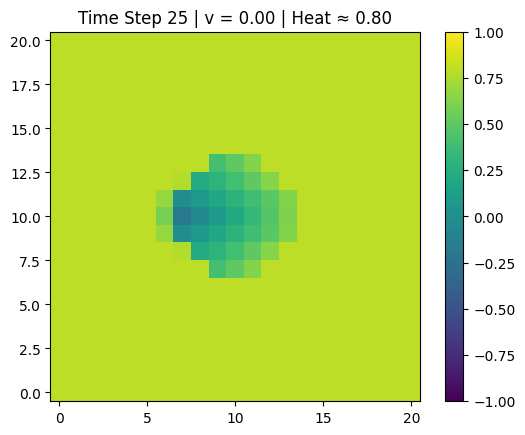

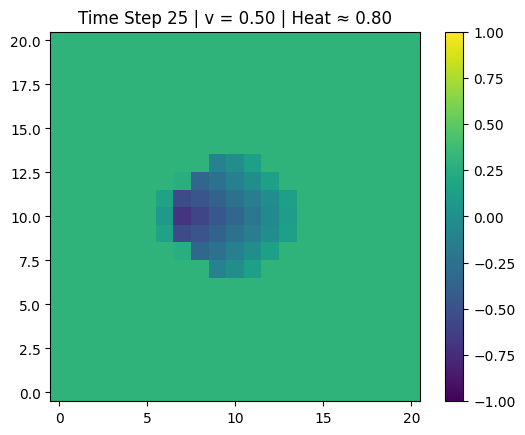

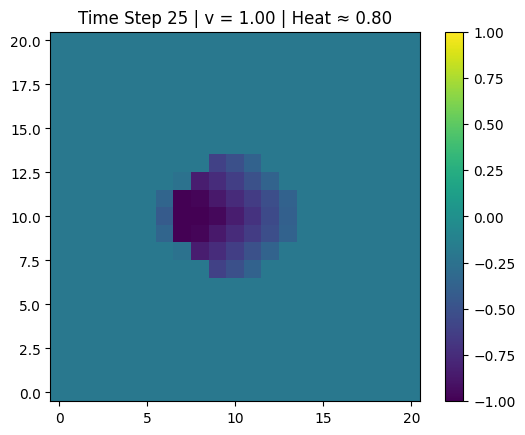

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import jax.numpy as jnp
import numpy as np
from itertools import product

# Define theta and heat values
theta_values = jnp.linspace(0, 2 * jnp.pi, dim)
vel_values = jnp.linspace(0, 1, dim)
heat_values = [0.2, 0.4, 0.6, 0.8]
thetas = [0.]
vels = [0., 0.5, 1.0]

# Normalize for consistent colormap scaling
norm = mcolors.Normalize(vmin=-1, vmax=1)

# Helper: find closest index
def find_closest_index(value, values):
    return jnp.argmin(jnp.abs(values - value))

# Dictionary to store results
saved_slices = {}

for heat_value, vel in product(heat_values, vels):
    for theta in thetas:
        heat_idx = find_closest_index(heat_value, jnp.linspace(0, 1, dim))
        theta_index = find_closest_index(theta, theta_values)
        vel_index = find_closest_index(vel, vel_values)

        slice_data = np.array(target_values[-1, :, :, theta_index, heat_idx, vel_index])
        
        # Use updated key format
        key = f"theta_{theta:.4f}_{vel:.4f}_{heat_value:.4f}_rad"
        saved_slices[key] = slice_data

        # Plot
        unsafe = slice_data
        im = plt.imshow(unsafe.T, origin='lower', norm=norm, cmap='viridis')
        plt.title(f"Time Step 25 | v = {vel_values[vel_index]:.2f} | Heat ≈ {heat_value:.2f}")
        plt.colorbar(im)
        plt.show()

# Save all slices
# np.savez(f"../gt_dubins/value_function_theta_v_heat_slices_{dim}.npz", **saved_slices)

In [ ]:
# world extents (replace with your config if you have them)
x_min, x_max = -2.0, 2.0
y_min, y_max = -2.0, 2.0
xs = np.linspace(x_min, x_max, dim)
ys = np.linspace(y_min, y_max, dim)
XX, YY = np.meshgrid(xs, ys, indexing="xy")

for heat_value, vel in product(heat_values, vels):
    for theta in thetas:
        heat_idx   = find_closest_index(heat_value, jnp.linspace(0, 1, dim))
        theta_idx  = find_closest_index(theta, theta_values)
        vel_idx    = find_closest_index(vel, vel_values)

        V = np.array(target_values[-1, :, :, theta_idx, heat_idx, vel_idx])  # shape (dim, dim)
        key = f"theta_{theta:.4f}_{vel:.4f}_{heat_value:.4f}_rad"
        saved_slices[key] = V

        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(
            V.T, origin='lower', cmap='viridis', norm=norm,
            extent=[x_min, x_max, y_min, y_max],  # makes axes world units
            aspect='equal'
        )

        # --- BRT contour: level set V(x,y) = 0 ---
        cs = ax.contour(
            XX, YY, V.T, levels=[0.0], colors='w', linewidths=2
        )
        ax.clabel(cs, fmt={0.0: "BRT (V=0)"}, inline=True, fontsize=9)

        ax.set_title(f"t = {target_values.shape[0]-1} | v ≈ {float(vel_values[vel_idx]):.2f} | heat ≈ {heat_value:.2f}")
        ax.set_xlabel("x"); ax.set_ylabel("y")
        plt.colorbar(im, ax=ax, label="V(x,y)")
        plt.tight_layout()
        plt.show()
